<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Решение конкурса на kaggle</b></h1>

# Первая часть. Исследование

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

## Загрузка данных 

In [2]:
# подтягиваю данные из гугл диска
!pip install -q gdown
!gdown 1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K -O train.csv
!gdown 1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r -O test.csv
!gdown 199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y -O submission.csv



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\arina\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
Downloading...
From: https://drive.google.com/uc?id=1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K
To: d:\школы\DLS\train.csv

  0%|          | 0.00/664k [00:00<?, ?B/s]
 79%|███████▉  | 524k/664k [00:03<00:00, 165kB/s]
100%|██████████| 664k/664k [00:04<00:00, 155kB/s]
100%|██████████| 664k/664k [00:04<00:00, 157kB/s]
Downloading...
From: https://drive.google.com/uc?id=1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r
To: d:\школы\DLS\test.csv

  0%|          | 0.00/218k [00:00<?, ?B/s]
100%|██████████| 218k/218k [00:00<00:00, 582kB/s]
100%|██████████| 218k/218k [00:00<00:00, 582kB/s]
Downloading...
From: https://drive.google.com/uc?id=199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y
To: d:\школы\DLS\submission.csv

  0%|          | 0.00/14.7k [00:00<?, ?B/s]
100%|██████████| 14.7k/14.7k [00:00<00:00, 13

Смотрю на размер датасета и случайные строки, чтобы примерно понимать, с какими данными я работаю. 

In [3]:
data = pd.read_csv('./train.csv')
data.shape

(5282, 20)

In [4]:
data.sample(5, random_state=42)

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
1448,9,45.40,418.8,Male,0,No,No,No,No phone service,DSL,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,1
4792,37,70.35,2552.9,Male,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,0
8,50,105.95,5341.8,Male,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,No,Yes,No,Yes,Yes,Month-to-month,No,Credit card (automatic),1
3964,44,100.10,4378.35,Male,0,No,No,Yes,No,Fiber optic,No,No,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),0
240,25,20.95,495.15,Male,0,Yes,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Bank transfer (automatic),0


В случайных строчках пропусков не оказалось, посмотрим на то, какие данные представлены в датасете внимательнее. 

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   object 
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non-null   object 
 13  HasTechSupportAccess      5282 non-null   object 
 14  HasOnlin

С виду никаких явных пропусков в данных нет. Таблицу с процентами пропущенных значений не имеет особо смысла строить. 

 Однако, стоит обратить внимание на то, что признак TotalSpent представлен типом object, несмотря на то, что это числовая переменная. Скорее всего, здесь есть скрытые пропуски. 

Приведу все значения в столбце к числовому формату, а все, что не получилось - станет Nan.

In [6]:
converted = pd.to_numeric(data['TotalSpent'], errors='coerce')
mask = converted.isna() & data['TotalSpent'].notna()
print(data.loc[mask, 'TotalSpent'].unique())

[' ']


В данных есть пустые строчки, которые мешают интепретировать весь столбец как числовый признак. Заменим эти пустые строчки на Nan. 

In [7]:
data['TotalSpent'] = pd.to_numeric(data['TotalSpent'], errors='coerce')
data['TotalSpent'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 5282 entries, 0 to 5281
Series name: TotalSpent
Non-Null Count  Dtype  
--------------  -----  
5273 non-null   float64
dtypes: float64(1)
memory usage: 41.4 KB


Теперь формат данных отображается корректно. Заполним пропуски медианой, так как она более устойчива к выбросам. 

На всякий случай фиксируем, сколько неизвестных значений было и какой медианой они заполнялись. 

In [8]:
median_value = data['TotalSpent'].median()

print(f'Кол-во Nan в TotalSpent : {data["TotalSpent"].isna().sum()}')
print(f'Заполнили NaN медианой TotalSpent = {median_value:.2f}')

data['TotalSpent'] = data['TotalSpent'].fillna(0)

Кол-во Nan в TotalSpent : 9
Заполнили NaN медианой TotalSpent = 1410.25


In [9]:
# списки с именами разных колонок для удобства дальнейшей работы

# числовые признаки
num_cols = ['ClientPeriod','MonthlySpending','TotalSpent']

# категориальные признаки
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

feature_cols = num_cols + cat_cols
target_col = 'Churn'

## Анализ данных


### Числовые признаки

Судя по информации о датасете, в данных 3 числовых признака: ClientPeriod, MontlySpending и TotalSpent. Построим гистограммы, чтобы понять, как они распределены. 

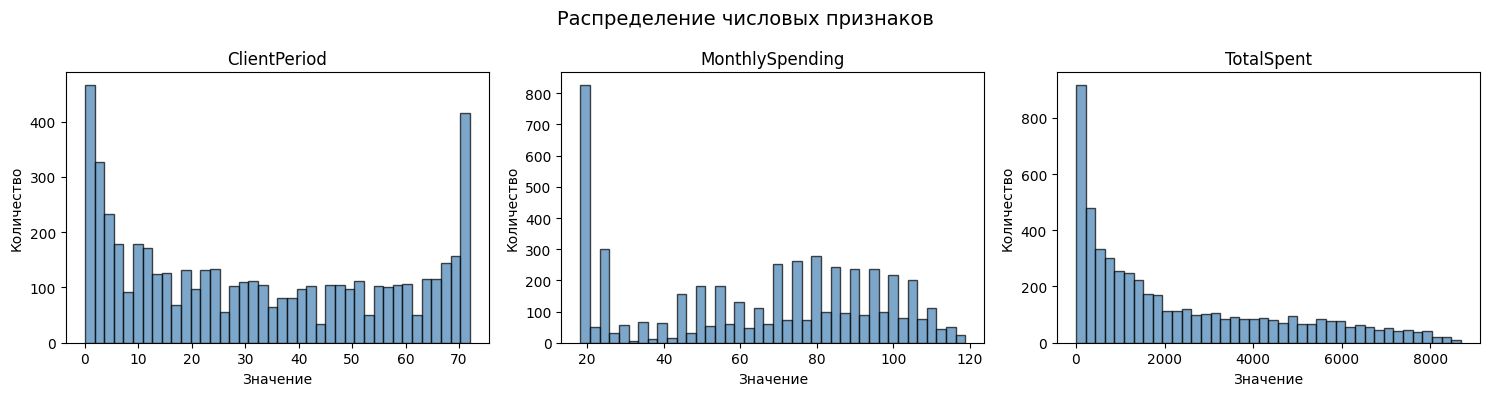

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Распределение числовых признаков', fontsize=14)

#использую названия колонок из списка num_cols
for ax, col in zip(axes, num_cols):
    ax.hist(data[col], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('Значение')
    ax.set_ylabel('Количество')
plt.tight_layout()
plt.show()

**Наблюдения по числовым признакам:**

- **ClientPeriod** - распределение почти равномерное с пиком у новых клиентов (0–5 месяцев) и у очен старых клиентов. Много клиентов уходят в первые месяцы.
- **MonthlySpending** - пик около 20 (скорее всего базовый тариф)
- **TotalSpent** - сильно скошено вправо, большинство клиентов потратили мало. Это ожидаемо: много новых клиентов с коротким стажем.

### Категориальные признаки

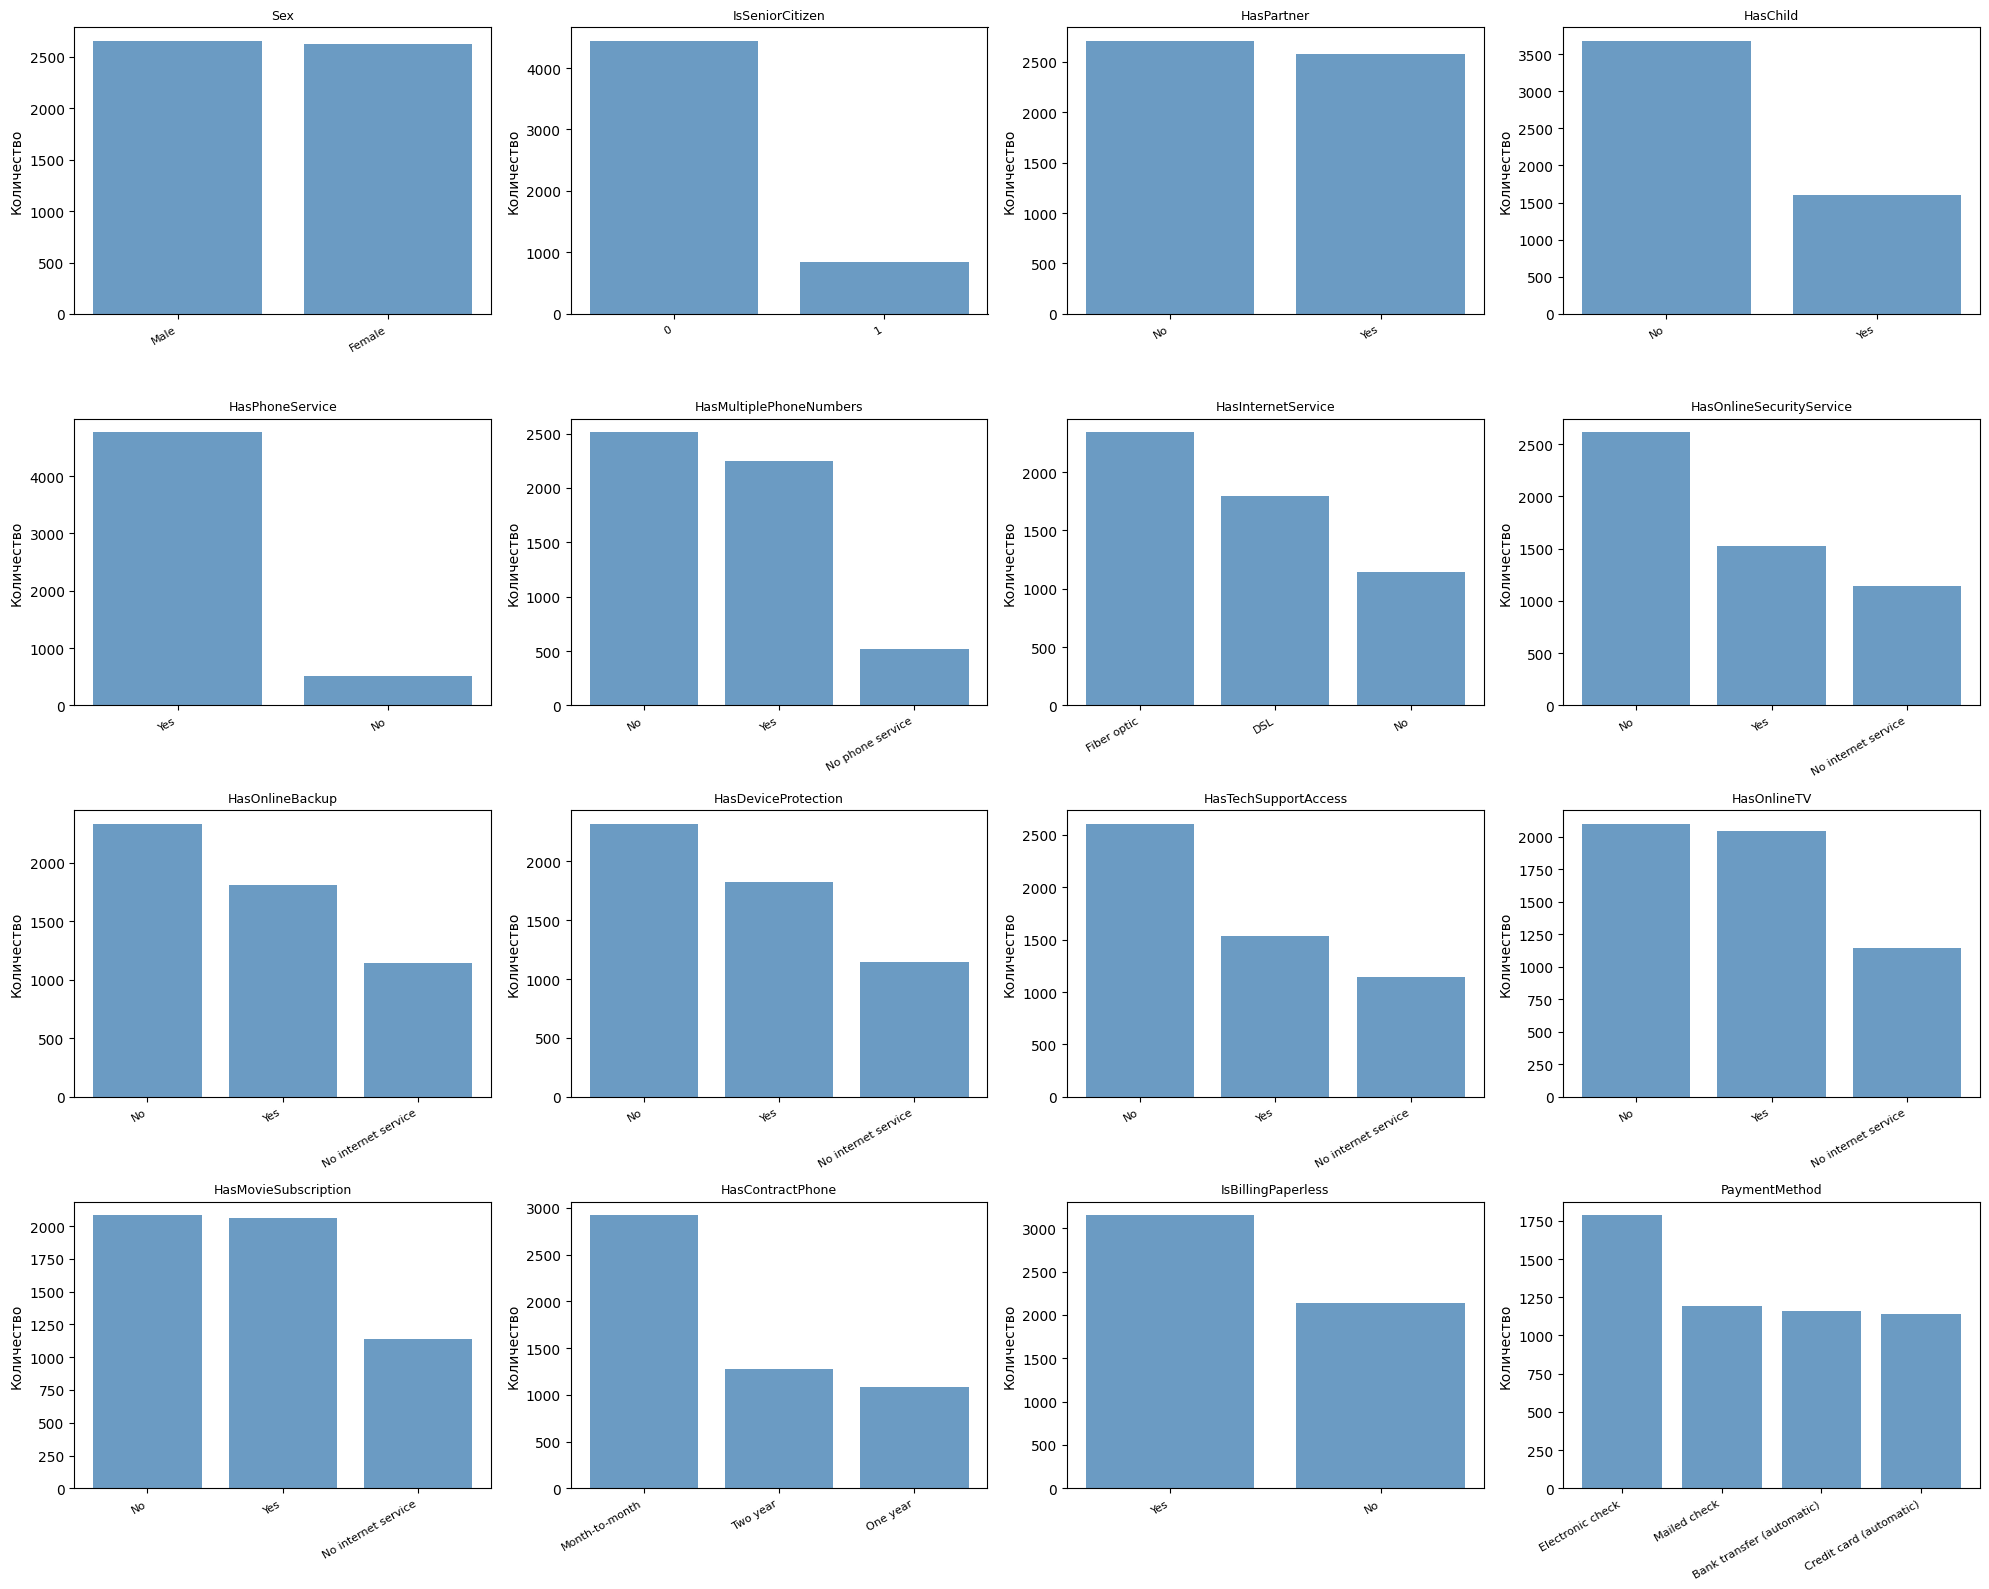

In [11]:
n = len(cat_cols) #кол-во категориальных признаков
cols_per_row = 4 #кол-во графиков в строке
rows = (n + cols_per_row - 1) // cols_per_row #вычисляем кол-во строк, округляя вверх

fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten() #превращаем 2D массив осей в 1D для удобства итерации

for i, col in enumerate(cat_cols):
    vc = data[col].value_counts()
    axes[i].bar(range(len(vc)), vc.values, color='steelblue', alpha=0.8)
    axes[i].set_xticks(range(len(vc)))
    axes[i].set_xticklabels(vc.index, rotation=30, ha='right', fontsize=8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('Количество')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False) #скрываем лишние оси, если категориальных признаков меньше, чем ячеек в сетке    

plt.tight_layout()
plt.show()


**Наблюдения по категориальным признакам:**

- **Sex** - распределение примерно равное, мужчин и женщин примерно поровну.
- **IsSeniorCitizen** - подавляющее большинство клиентов не пенсионеры (~84%).
-  **HasPartner** - распределение примерно равное, обеих категорий примерно поровну.
-  **HasChild** - у большей части клиентов детей нет.
- **HasPhoneService** - почти все клиенты имеют телефон (~90%), признак слабо информативен.
- **HasInternetService** - три категории: Fiber optic, DSL, No. Fiber optic — самая популярная.
- **HasOnlineSecurityService, HasOnlineBackup, HasDeviceProtection, HasTechSupportAccess, HasOnlineTV, HasMovieSubscription** — у всех одинаковая структура: No > Yes > No internet service. Это логично — часть клиентов без интернета автоматически не имеет этих услуг.
- **HasContractPhone** - большинство на помесячном контракте, меньше на годовых и двухлетних.
- **IsBillingPaperless** - чуть больше клиентов с электронным выставлением счетов.
- **PaymentMethod** - четыре способа оплаты распределены примерно равномерно.

### Распределение целевой переменной

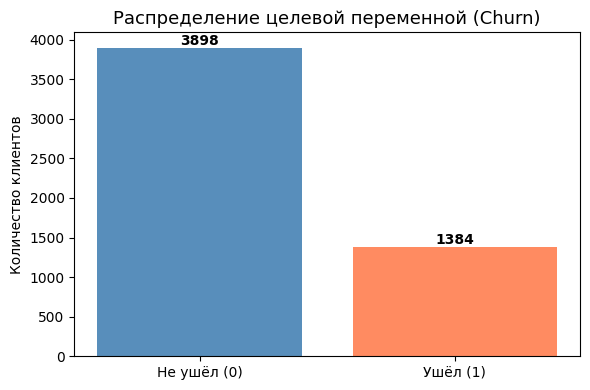

Churn rate: 26.20%


In [12]:
churn_counts = data[target_col].value_counts() #подсчитываем количество объектов в каждом классе в целевой переменной

fig = plt.figure(figsize=(6, 4))
plt.title('Распределение целевой переменной (Churn)', fontsize=13)
plt.bar(['Не ушёл (0)', 'Ушёл (1)'], churn_counts.values, color=['steelblue', 'coral'], alpha=0.9)
plt.ylabel('Количество клиентов')
for idx, v in enumerate(churn_counts.values):
    plt.text(idx, v + 30, str(v), ha='center', fontweight='bold') #сдвигаем цифры на 30 верх над столбцами для лучшей читаемости
plt.tight_layout()
plt.show()

print(f'Churn rate: {data[target_col].mean():.2%}')

Классы не сбалансированы: ушли около 26%, остались около 74%. 

### Анализ выбросов

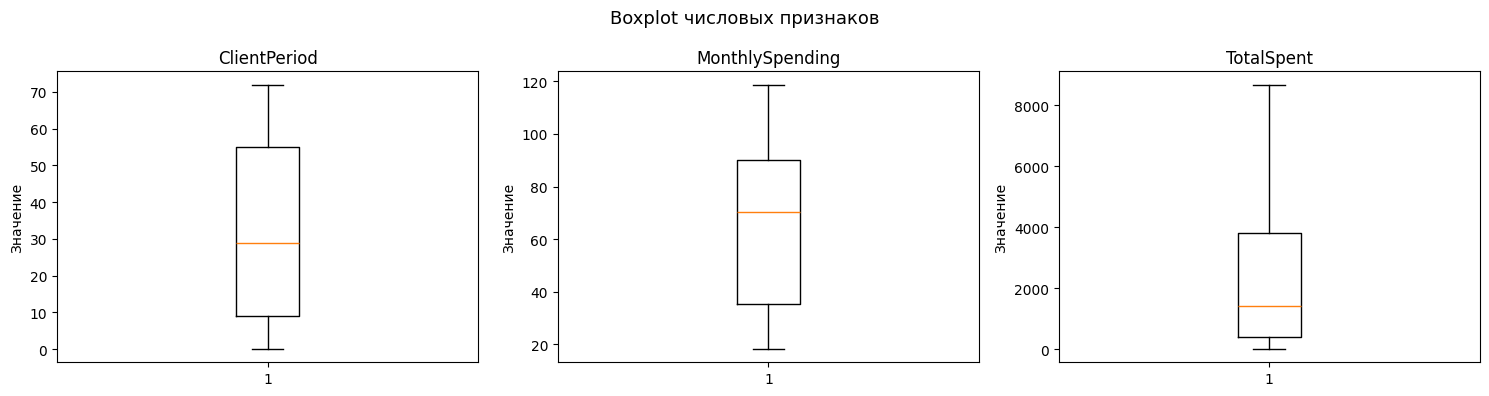

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Boxplot числовых признаков', fontsize=13)

for ax, col in zip(axes, num_cols):
    ax.boxplot(data[col], vert=True)
    ax.set_title(col)
    ax.set_ylabel('Значение')
plt.tight_layout()
plt.show()


ClientPeriod и MonthlySpending выглядят нормально. У TotalSpent длинный верхний хвост (правоскошенное распределение), большие значения здесь физически осмысленны: клиенты с долгим стажем и высоким тарифом накопили большую сумму.

## Применение линейных моделей

In [14]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.model_selection import  GridSearchCV

Запишу все признаки в переменную X, а таргет - в переменную y для удобства работы. 

Провожу препроцессинг: стандартизирую числовые признаки через StandardScaler и  кодирую категориальные признаки. Кодировать буду с помощью OneHotEncoding, так как в данных нет порядковых признаков. Передам в качестве параметра drop='first', чтобы убрать мультиколлинеарность. Бинарные признаки тоже нормально преобразуются через этот класс (произойдет замена классов на 0/1 и останется так же один столбец), поэтому передаю в класс весь список cat_cols.

In [15]:
X = data[feature_cols].copy() #создаю копию датафрейма с признаками, чтобы не изменять оригинальный датафрейм при препроцессинге
y = data[target_col]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])

Я воспользуюсь Pipeline и передам туда препроцессор и логистическую регрессию, а так же использую GridSearchCV, который будет сам разбивать данные на train и valid 5 раз (выбранный мною гиперпараметр). Наилучшая модель будет выбираться по roc_auc, перебор будет происходить по заданным в списке значениям регуляризации C.

Кроме того, учитывая дисбаланс классов, в регрессии задам параметр class_weight='balanced'.

In [16]:
pipe = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=13, class_weight='balanced'))
])

C = [0.001, 0.01, 0.1, 1, 10, 100]
grid = GridSearchCV(
    pipe, #указываем пайплайн, который включает препроцессинг и модель
    param_grid={'model__C': C}, #указываем, что хотим перебрать разные значения параметра C в модели LogisticRegression, который находится на этапе 'model' в пайплайне
    scoring='roc_auc',
    cv=5,
    refit=True  # после подбора переобучит лучшую модель на всём X
)

grid.fit(X, y)
print(f'Лучший параметр C: {grid.best_params_["model__C"]}')
print(f'Лучший ROC-AUC (средний по 5 фолдам): {grid.best_score_:.4f}')


Лучший параметр C: 100
Лучший ROC-AUC (средний по 5 фолдам): 0.8448


## Применение градиентного бустинга


Применяю градиентный бустинг с помощью Catboost. Делю вручную трейновую выборку на train и valid (в соотношении 80 на 20 + указываю, что нужно сохранять пропорции таргета через параметр stratify). Тестирую модель с параметрами по умолчанию. 

In [17]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# для CatBoost категориальные признаки не кодируем, передаём как есть
X_catboost = data[feature_cols].copy()
y_catboost = data[target_col]

# разбиваю на train и val, stratify=y_catboost для сохранения пропорции классов в обоих наборах
X_train, X_val, y_train, y_val = train_test_split(X_catboost, y_catboost, 
          test_size=0.2, random_state=13, stratify=y_catboost)

# параметры по умолчанию, ничего не меняю
catboost_default = CatBoostClassifier(
    cat_features=cat_cols,
    random_seed=13,
    verbose=0, # отключаем вывод обучения в консоль для чистоты вывода результатов
    auto_class_weights='Balanced' #автоматически балансируем классы внутри CatBoost
)

catboost_default.fit(X_train, y_train)
score_default = roc_auc_score(y_val, catboost_default.predict_proba(X_val)[:, 1])
print(f'CatBoost (default): ROC-AUC = {score_default:.4f}')

CatBoost (default): ROC-AUC = 0.8257


Экспериментирую с гиперпараметрами catboost, а именно с количеством деревьев и со скоростью обучения. 

In [18]:
# подбираю гиперпараметры: n_estimators и learning_rate
best_score = 0
best_params = {}

# двойной цикл для перебора всех комбинаций n_estimators и learning_rate
for n_est in [300, 500, 800]:
    for lr in [0.03, 0.05, 0.1]:
        cb = CatBoostClassifier(
            iterations=n_est,
            learning_rate=lr,
            cat_features=cat_cols,
            random_seed=42,
            verbose=0,
            auto_class_weights='Balanced'
        )
        cb.fit(X_train, y_train)
        score = roc_auc_score(y_val, cb.predict_proba(X_val)[:, 1])
        print(f'iterations={n_est}, lr={lr:.2f} - ROC-AUC={score:.4f}')
        if score > best_score:
            best_score = score
            best_params = {'iterations': n_est, 'learning_rate': lr}

print(f'Лучшие параметры: {best_params}')
print(f'Лучший ROC-AUC: {best_score:.4f}')

iterations=300, lr=0.03 - ROC-AUC=0.8282
iterations=300, lr=0.05 - ROC-AUC=0.8298
iterations=300, lr=0.10 - ROC-AUC=0.8194
iterations=500, lr=0.03 - ROC-AUC=0.8277
iterations=500, lr=0.05 - ROC-AUC=0.8267
iterations=500, lr=0.10 - ROC-AUC=0.8136
iterations=800, lr=0.03 - ROC-AUC=0.8260
iterations=800, lr=0.05 - ROC-AUC=0.8211
iterations=800, lr=0.10 - ROC-AUC=0.8057
Лучшие параметры: {'iterations': 300, 'learning_rate': 0.05}
Лучший ROC-AUC: 0.8298


### Подбор гиперпараметров CatBoost с помощью Optuna

GridSearchCV перебирает все комбинации из заданной сетки. Это оказывается долго и негибко. Испольлзую Optuna, она использует байесовскую оптимизацию, то есть на основе предыдущих попыток предсказывает, какие параметры стоит попробовать следующими. За меньшее число попыток Optuna часто находит лучшую комбинацию, чем GridSearchCV за большее. 

In [19]:
import optuna

X_fit, X_val, y_fit, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

def objective(trial):
    # задаю пространство поиска гиперпараметров
    param = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-1, 10.0, log=True),
        'auto_class_weights': 'Balanced', # для баланса
        'eval_metric': 'ROC-AUC',
        'random_seed': 12,
        'logging_level': 'Silent' # чтобы не мусорить в выводе
    }

    # инициализирую и обучаем модель
    model = CatBoostClassifier(**param)
    
    # cat_features передаю прямо в fit
    model.fit(
        X_fit, y_fit,
        eval_set=[(X_val, y_val)],
        cat_features=cat_cols,
        early_stopping_rounds=50 # Остановит обучение, если метрика перестанет расти
    )

    # делаю предсказание вероятностей и считаем ROC-AUC
    preds = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds)
    
    return auc

# создаем исследование, максимизируем метрику
study = optuna.create_study(direction='maximize')
# запускаю поиск на 30 попыток (trials)
study.optimize(objective, n_trials=30)

print(f"Лучший ROC-AUC: {study.best_value:.4f}")
print("Лучшие параметры:", study.best_params)

[I 2026-04-07 16:13:59,822] A new study created in memory with name: no-name-16711756-f7e3-44d0-9d52-5a73866a638e
[W 2026-04-07 16:13:59,918] Trial 0 failed with parameters: {'iterations': 528, 'learning_rate': 0.024008353439412843, 'depth': 7, 'l2_leaf_reg': 9.521750442984924} because of the following error: CatBoostError("tools/enum_parser/enum_serialization_runtime/enum_runtime.cpp:70: Key 'ROC-AUC' not found in enum ELossFunction. Valid options are: 'Logloss', 'CrossEntropy', 'CtrFactor', 'Focal', 'RMSE', 'LogCosh', 'Lq', 'MAE', 'Quantile', 'MultiQuantile', 'Expectile', 'LogLinQuantile', 'MAPE', 'Poisson', 'MSLE', 'MedianAbsoluteError', 'SMAPE', 'Huber', 'Tweedie', 'Cox', 'RMSEWithUncertainty', 'MultiClass', 'MultiClassOneVsAll', 'PairLogit', 'PairLogitPairwise', 'YetiRank', 'YetiRankPairwise', 'QueryRMSE', 'GroupQuantile', 'QuerySoftMax', 'QueryCrossEntropy', 'StochasticFilter', 'LambdaMart', 'StochasticRank', 'PythonUserDefinedPerObject', 'PythonUserDefinedMultiTarget', 'UserPerO

CatBoostError: tools/enum_parser/enum_serialization_runtime/enum_runtime.cpp:70: Key 'ROC-AUC' not found in enum ELossFunction. Valid options are: 'Logloss', 'CrossEntropy', 'CtrFactor', 'Focal', 'RMSE', 'LogCosh', 'Lq', 'MAE', 'Quantile', 'MultiQuantile', 'Expectile', 'LogLinQuantile', 'MAPE', 'Poisson', 'MSLE', 'MedianAbsoluteError', 'SMAPE', 'Huber', 'Tweedie', 'Cox', 'RMSEWithUncertainty', 'MultiClass', 'MultiClassOneVsAll', 'PairLogit', 'PairLogitPairwise', 'YetiRank', 'YetiRankPairwise', 'QueryRMSE', 'GroupQuantile', 'QuerySoftMax', 'QueryCrossEntropy', 'StochasticFilter', 'LambdaMart', 'StochasticRank', 'PythonUserDefinedPerObject', 'PythonUserDefinedMultiTarget', 'UserPerObjMetric', 'UserQuerywiseMetric', 'R2', 'NumErrors', 'FairLoss', 'AUC', 'Accuracy', 'BalancedAccuracy', 'BalancedErrorRate', 'BrierScore', 'Precision', 'Recall', 'F1', 'TotalF1', 'F', 'MCC', 'ZeroOneLoss', 'HammingLoss', 'HingeLoss', 'Kappa', 'WKappa', 'LogLikelihoodOfPrediction', 'NormalizedGini', 'PRAUC', 'P

Выше всего roc-auc оказался у catboost с указанными параметрами (чуть выше, чем у логрегрессии). Запишем эту модель и обучим ее уже на всей обучающей выборке.

In [ ]:
best_params = study.best_params.copy()  # копия, чтобы не менять оригинал

best_model = CatBoostClassifier(
    iterations=best_params['iterations'],
    learning_rate=best_params['learning_rate'],
    depth=best_params['depth'],
    l2_leaf_reg=best_params['l2_leaf_reg'],
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0
)

best_model.fit(X, y, cat_features=cat_cols)

# Предсказания

Сохраняю лучшую модель. 

In [ ]:
X_test = pd.read_csv('test.csv')

# конвертируем TotalSpent в test так же, как в train
X_test['TotalSpent'] = pd.to_numeric(X_test['TotalSpent'], errors='coerce')
X_test['TotalSpent'] = X_test['TotalSpent'].fillna(X_test['TotalSpent'].median())


# создаю новый DataFrame для submission
my_submission = pd.DataFrame({
    'Id': range(len(X_test)),
    'Churn': best_model.predict_proba(X_test[feature_cols])[:, 1]
})

my_submission.to_csv('my_submission.csv', index=False)
my_submission.head()


,Id,Churn
0,0,0.048671
1,1,0.851097
2,2,0.813433
3,3,0.040290
4,4,0.010495
